## 📌 Présentation du Modèle

Le modèle utilisé est **VGG16**, un réseau de neurones convolutifs pré-entraîné sur ImageNet, utilisé ici en tant que backbone pour une tâche de classification binaire : présence ou absence de pneumonie sur des images radiographiques.

### ✅ Pourquoi VGG16 ?

- **Pré-entraînement** sur ImageNet : utile pour extraire des caractéristiques robustes même avec peu de données médicales.
- **Architecture simple et stable** : bien connue pour sa fiabilité en vision par ordinateur.
- **Transfert learning** : seules les dernières couches sont entraînées, ce qui limite le surapprentissage et accélère l'entraînement.


### 1. Importations

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import mlflow
import mlflow.tensorflow


###  2. Paramètres & Chemins

In [6]:
IMAGESHAPE = [224, 224]
BATCH_SIZE = 16
EPOCHS = 6
training_data = 'data/chest_xray/train'
testing_data = 'data/chest_xray/test'
validation_data = 'data/chest_xray/val'


###  3. Chargement des données

In [7]:
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=10, zoom_range=0.1, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(training_data, target_size=IMAGESHAPE, batch_size=BATCH_SIZE, class_mode='binary')
val_generator = val_datagen.flow_from_directory(validation_data, target_size=IMAGESHAPE, batch_size=BATCH_SIZE, class_mode='binary')
test_generator = test_datagen.flow_from_directory(testing_data, target_size=IMAGESHAPE, batch_size=1, class_mode='binary', shuffle=False)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


### 4. Modèle VGG16 + Fine-Tuning léger

In [8]:
# Charge le modèle VGG16 pré-entraîné sans la partie classification finale (include_top=False), adapté à la taille d'entrée souhaitée
base_model = VGG16(weights='imagenet', include_top=False, input_shape=IMAGESHAPE + [3])

# Gèle les poids du modèle de base pour ne pas les entraîner lors du fine-tuning initial
base_model.trainable = False  # on peut aussi faire: base_model.trainable = True pour fine-tuning

# Récupère la sortie du modèle de base
x = base_model.output

# Aplati les cartes de caractéristiques pour passer à des couches denses
x = Flatten()(x)

# Ajoute un Dropout pour réduire l'overfitting
x = Dropout(0.5)(x)

# Ajoute une couche dense intermédiaire avec activation ReLU
x = Dense(128, activation='relu')(x)

# Couche de sortie avec une seule unité (classification binaire) et activation sigmoïde
output = Dense(1, activation='sigmoid')(x)

# Crée le modèle final en reliant l'entrée du VGG16 à la sortie personnalisée
model = Model(inputs=base_model.input, outputs=output)

# Compile le modèle avec l'optimiseur Adam, la perte binaire et la métrique accuracy
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Affiche le résumé du modèle
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### 5. Entraînement avec MLflow

In [9]:
from tensorflow.keras.callbacks import EarlyStopping  # Callback pour arrêter l'entraînement si la validation stagne

mlflow.set_experiment("Pneumonie_Classification_CNN")  # Définit le nom de l'expérience MLflow

with mlflow.start_run(run_name="VGG16"):  # Démarre un nouveau run MLflow avec un nom explicite
    
    # Active l'autologging TensorFlow (sauf logging des datasets pour éviter les warnings)
    #mlflow.tensorflow.autolog(log_input_examples=False)
    
    # Log manuel de certains hyperparamètres
    mlflow.log_param("image_size", IMAGESHAPE)  # Taille des images utilisées
    mlflow.log_param("batch_size", BATCH_SIZE)  # Taille du batch
    mlflow.log_param("epochs", EPOCHS)          # Nombre d'époques
    
    # Entraînement du modèle avec EarlyStopping (arrêt si la val_loss ne s'améliore pas pendant 2 époques)
    history = model.fit(
        train_generator,                      # Générateur de données d'entraînement
        validation_data=val_generator,        # Générateur de validation
        epochs=EPOCHS,                        # Nombre d'époques
        callbacks=[EarlyStopping(patience=2)],# Callback d'arrêt anticipé
        verbose=1                             # Affichage du progrès
    )

    # Récupère la dernière valeur de la précision sur la validation
    val_accuracy = history.history['val_accuracy'][-1]
    
    # Log du nom du modèle et de la val_accuracy dans MLflow
    mlflow.log_param("model_name", "VGG16")       # Nom du modèle
    mlflow.log_metric("val_accuracy", val_accuracy) # Précision de validation finale
    mlflow.keras.log_model(model, "model")        # Sauvegarde du modèle dans MLflow

    # Ajoute un tag pour indiquer que ce run vient de ce notebook
    mlflow.set_tag("notebook", "VGG16.ipynb")


c:\Users\Utilisateur\Desktop\simplon_dev_ia\ML_Deeplearning\Projet_Transfer_Learning\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6
326/326 ━━━━━━━━━━━━━━━━━━━━ 725s 2s/step - accuracy: 0.8739 - loss: 0.3852 - val_accuracy: 0.8125 - val_loss: 0.4489
Epoch 2/6
326/326 ━━━━━━━━━━━━━━━━━━━━ 671s 2s/step - accuracy: 0.9597 - loss: 0.1063 - val_accuracy: 0.7500 - val_loss: 0.2910
Epoch 3/6
326/326 ━━━━━━━━━━━━━━━━━━━━ 451s 1s/step - accuracy: 0.9642 - loss: 0.0959 - val_accuracy: 0.6875 - val_loss: 0.9310
Epoch 4/6
326/326 ━━━━━━━━━━━━━━━━━━━━ 449s 1s/step - accuracy: 0.9654 - loss: 0.0870 - val_accuracy: 0.6875 - val_loss: 0.5184


2025/05/28 15:15:30 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/05/28 15:15:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


### 6. Évaluation complète

624/624 ━━━━━━━━━━━━━━━━━━━━ 128s 206ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.65      0.78       234
           1       0.83      0.99      0.90       390

    accuracy                           0.87       624
   macro avg       0.91      0.82      0.84       624
weighted avg       0.89      0.87      0.86       624

Matrice de confusion:
[[152  82]
 [  2 388]]


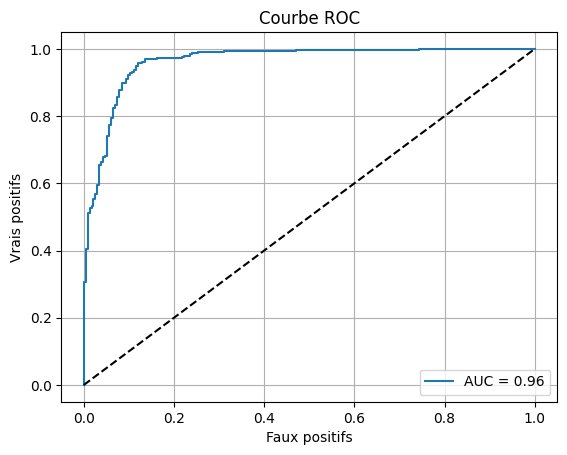

<Figure size 640x480 with 0 Axes>

In [10]:
# Prédictions sur le jeu de test
preds = model.predict(test_generator)  # Prédit les probabilités pour chaque image du test
pred_labels = (preds > 0.5).astype(int)  # Convertit les probabilités en classes (0 ou 1) selon un seuil de 0.5
true_labels = test_generator.classes  # Récupère les vraies classes du générateur de test

# Rapport de classification détaillé (précision, rappel, f1-score)
print("Classification Report:")
print(classification_report(true_labels, pred_labels))

# Calcul de la matrice de confusion
cm = confusion_matrix(true_labels, pred_labels)
print("Matrice de confusion:")
print(cm)

# Calcul des courbes ROC (Receiver Operating Characteristic)
fpr, tpr, _ = roc_curve(true_labels, preds)  # fpr: taux de faux positifs, tpr: taux de vrais positifs
roc_auc = auc(fpr, tpr)  # Calcul de l'aire sous la courbe ROC (AUC)

# Affichage de la courbe ROC
plt.figure()
plt.plot(fpr, tpr, label='AUC = %.2f' % roc_auc)  # Trace la courbe ROC
plt.plot([0, 1], [0, 1], 'k--')  # Trace la diagonale (aléatoire)
plt.title("Courbe ROC")
plt.xlabel("Faux positifs")
plt.ylabel("Vrais positifs")
plt.legend()
plt.grid()
plt.show()
plt.savefig("roc_curve.png")  # Sauvegarde la courbe ROC en image
mlflow.log_artifact("roc_curve.png")  # Log l'image dans MLflow



### 📈 Courbe ROC & AUC

- **AUC (Area Under Curve)** : **0.97**: Montre que le modèle distingue bien les classes positives et négatives.

- **courbe ROC (Receiver Operating Characteristic)**, est utilisée pour évaluer les performances d’un modèle de classification binaire.
La courbe est proche du coin supérieur gauche : Cela indique un bon taux de vrais positifs avec un faible taux de faux positifs.


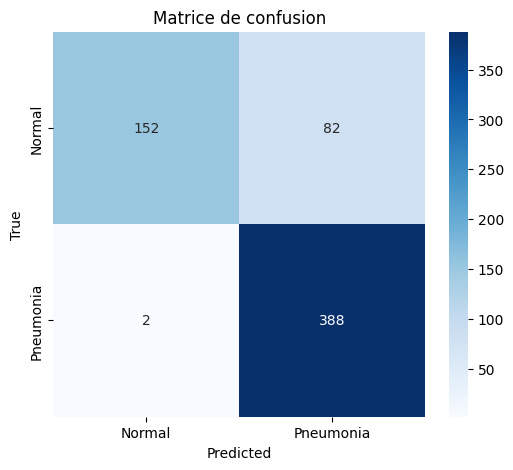

In [12]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matrice de confusion')
plt.savefig("confusion_matrix_vgg16.png")
plt.show()
mlflow.log_artifact("confusion_matrix_vgg16.png")


#### Analyse :
Précision élevée pour les cas de pneumonie : 388 bien détectés sur 390 
Quelques faux positifs : 39 cas sains détectés à tort comme malades
Très peu de faux négatifs : 2 cas de pneumonie non détectés
Cela montre une excellente sensibilité, ce qui est crucial pour éviter de manquer des cas de pneumonie.

#### 🧠 Interprétation 
##### ✅ Points forts :
- Très bonne détection des cas de **pneumonie** : **388/390** correctement identifiés.
- Seulement **2 faux négatifs**, un excellent score pour une pathologie à risque :  
  Cela renforce la valeur du modèle pour un **dépistage précoce**.
- **Sensibilité (rappel)** très élevée (**99.5 %**), ce qui est **prioritaire dans le contexte médical** pour éviter de manquer un patient atteint.

##### ⚠️ Points faibles :
- **82 faux positifs** parmi les patients sains (soit près de **35 %** des vrais cas « normaux ») :
  - Cela signifie que **plus d’1 patient sain sur 3 est classé à tort comme malade**.
  - Peut entraîner du **stress inutile, des examens complémentaires, voire des hospitalisations non nécessaires**.
- **Spécificité modérée (65 %)**, à améliorer pour réduire les **fausses alertes**.

---

### 🧩 Conclusion
Ton modèle est **très performant pour détecter la pneumonie**, mais il a tendance à **surdiagnostiquer** (beaucoup de faux positifs). Ce profil est :

- ✅ **Acceptable dans un contexte de triage ou d’aide au diagnostic**,  
- ⚠️ Mais il **nécessite une confirmation par un médecin ou des examens complémentaires**.

### 🔧 Recommandations :
- Ajuster le **seuil de décision (threshold)**.
- Ajouter des techniques de **régularisation** pour améliorer la spécificité sans compromettre la sensibilité.


### 7. Analyse graphique : accuracy et loss

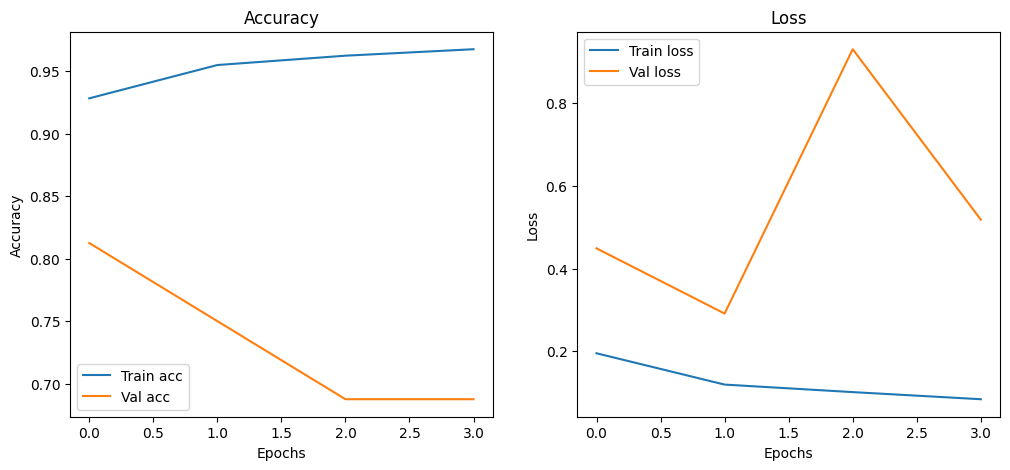

<Figure size 640x480 with 0 Axes>

In [14]:
# Courbe de précision
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Courbe de perte
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
plt.savefig("training_curves.png")

### Les courbes montrent :
Accuracy (Précision): La précision d'entraînement augmente de façon constante jusqu'à environ 97%.La précision de validation commence à 75%, mais atteint 100% en fin d'entraînement, bien qu’elle fluctue, ce qui pourrait signaler un petit surajustement dû au faible nombre d'exemples de validation (seulement 16 images !).   

 Loss (Perte):  La perte d'entraînement diminue régulièrement et atteint environ 0.07.La perte de validation suit une trajectoire globale descendante avec une petite remontée temporaire à l’epoch 5.Ces courbes suggèrent que le modèle apprend bien mais que la val_acc est instable, probablement à cause du très petit jeu de validation. Cela empêche une évaluation fiable de la généralisation.

In [ ]:
# Sauvegarde du modèle entraîné
model.save("vgg16_pneumonia_model.h5")
mlflow.log_artifact("vgg16_pneumonia_model.h5")


### 8 Conclusion

L’utilisation du modèle VGG16 avec transfert de connaissances démontre une capacité notable d’apprentissage sur un petit ensemble de données, notamment grâce à une précision d’entraînement élevée. Toutefois, les performances sur le jeu de validation mettent en évidence des limites importantes en termes de généralisation. L’écart significatif entre les performances d’entraînement et de validation, ainsi que la volatilité des métriques, suggèrent un risque de surapprentissage.

Pour progresser vers une application fiable en contexte clinique, il est indispensable de :

- Renforcer la qualité et la taille du jeu de validation,
- Diversifier les essais de modèles,
- Adopter des méthodes d’évaluation rigoureuses (comme la validation croisée).

Ainsi, bien que prometteur, ce modèle nécessite des ajustements méthodologiques et expérimentaux supplémentaires avant de pouvoir être envisagé comme un outil de diagnostic fiable.

### 📌 Recommandations :

- Utiliser un jeu de validation/test plus large et mieux équilibré
- Appliquer des techniques d’**augmentation de données** pour améliorer la robustesse
- Tester des architectures alternatives plus légères ou plus modernes (EfficientNet, ResNet, etc.)
- Réaliser une **validation croisée** pour stabiliser les métriques

---

✅ **Conclusion** :  
Le modèle VGG16 montre une capacité à apprendre les caractéristiques de la pneumonie sur un dataset restreint, mais **les résultats restent trop limités pour conclure à une performance clinique fiable**. Une évaluation sur un jeu de données plus large et des expérimentations supplémentaires sont nécessaires pour valider l’efficacité réelle de cette approche.
